# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [1]:
ПІБ = 'Іванів Христина Вікторівна'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-34'      # напр. 'КН-31'
ВАРІАНТ = 4     # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [2]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Іванів Христина Вікторівна, ШІ-34, варіант 4
ваш потік:                   P>100
ваша пара для графіка 3:     радіопотік F10.7 та швидкість вітру
ваш агрегат для етапу 4:     максимум
ваше додаткове питання:      Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [4]:
excel_file = pd.read_excel(ФАЙЛ)  
display(excel_file.head(10))
print(excel_file.dtypes)


,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
5,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >30 = Particles at >30 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Unnamed: 0                                     float64
ftp://ftp.swpc.noaa.gov/pub/lists/particle/     object
Unnamed: 2                                      object
Unnamed: 3                                      object
Unnamed: 4                                      object
Unnamed: 5                                      object
Unnamed: 6                                      object
Unnamed: 7                                      object
Unnamed: 8                                      object
Unnamed: 9                                      object
Unnamed: 10                                     object
Unnamed: 11                                     object
Unnamed: 12                                     object
Unnamed: 13                                     object
Unnamed: 14                                     object
Unnamed: 15                                    float64
Unnamed: 16                                     object
Unnamed: 17                                     object
Unnamed: 1

**Відповідь 1.1:** *(чому звичайне читання дало саме такий результат)*

Замість заголовків таблиці pandas прочитав перший рядок аркуша, хоча там лежить не заголовок, а метадані: звідки взяті дані, коли їх вивантажено, та підписи величин. Тому назви стовпців вийшли або цим випадковим текстом, або автоматичними Unnamed: N. Заодно постраждали й типи даних: колонки, які мали містити тільки цифри, pandas визначив як object, бо в тих же клітинках трапляється і текст описового рядка. Також на аркуші склеєно кілька різних таблиць одна біля одної, і при читанні через read_excel вони перетворюються на одну суцільну таблицю.

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [5]:
excel_file = pd.read_excel(ФАЙЛ, header=None)
print(excel_file.shape)
excel_file.head(30)


(7226, 32)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [6]:
excel_file = pd.read_excel(ФАЙЛ, header=None)
print(excel_file.notna().sum())

0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64


**Відповідь 1.3:** *(скільки таблиць і які стовпці кожна займає)*

Можна зробити висновок, що на аркуші три таблиці:
1. 1-14 стовпці
2. 16-19 стовпці
3. 24-31 стовпці

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [7]:
pd.set_option('display.max_colwidth', None)

print("ТАБЛИЦЯ A (стовпець 1, ftp NOAA/GOES)")
print(excel_file.iloc[:13, 1].to_string())

print("\n ТАБЛИЦЯ B (стовпці 16-19, ftp NOAA/F10.7)")
print(excel_file.iloc[:16, 16:20].to_string())

print("\n ТАБЛИЦЯ C (стовпці 24-31, SOHO)")
print(excel_file.iloc[:8, 24:32].to_string())


ТАБЛИЦЯ A (стовпець 1, ftp NOAA/GOES)
0                                         ftp://ftp.swpc.noaa.gov/pub/lists/particle/
1                                                                                 NaN
2                                                 :Data_list: 20170901_Gs_part_5m.txt
3                                                      :Created: 2017 Sep 02 0011 UTC
4     # Prepared by the U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center
5                  # Please send comments and suggestions to SWPC.Webmaster@noaa.gov 
6                                                                                  # 
7                                                # Label: P > 1 = Particles at >1 Mev
8                                                # Label: P > 5 = Particles at >5 Mev
9                                               # Label: P >10 = Particles at >10 Mev
10                                              # Label: P >30 = Particles at >30 Mev
11              

**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A | NOAA SWPC, супутник GOES-15, файл 20170901_Gs_part_5m.txt (потоки частинок) | потоки частинок різної енергії (P>1, P>5, P>10 Mev тощо) — у частинках/см²·с·стерадіан |
| B | NOAA SWPC, файл 2017Q3_DSD.txt (добові сонячні індекси, F10.7) | сонячний радіопотік F10.7, у сонячних потокових одиницях (sfu) |
| C | SOHO CELIAS Proton Monitor (http://umtof.umd.edu/pm/crn/) | швидкість протонів — км/с (km/sec); густина протонів — частинок/см³ (protons per cubic centimeter) |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [8]:
A = excel_file.iloc[:, 1:15].apply(pd.to_numeric, errors='coerce')
A.columns = ['рік','місяць','день','години_хвилин','julian_day','сек',
'P>1','P>5','P>10','P>30','P>50','P>100','E>0.8','E>2.0']
A = A.dropna(subset=['рік','місяць','день']).reset_index(drop=True)

B = excel_file.iloc[:, 16:20].apply(pd.to_numeric, errors='coerce')
B.columns = ['рік','місяць','день','F10.7']
B = B.dropna().reset_index(drop=True)

C = excel_file.iloc[:, 26:32].apply(pd.to_numeric, errors='coerce')
C.columns = ['рік','місяць','день','година','швидкість вітру','густина вітру']
C = C.dropna(subset=['рік','місяць','день']).reset_index(drop=True)

print(A.shape, B.shape, C.shape)

(7200, 14) (25, 4) (601, 6)


### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [9]:
A['година'] = (A['години_хвилин'] // 100).astype(int)
A['хвилина'] = (A['години_хвилин'] % 100).astype(int)
A['ts'] = pd.to_datetime(dict(
    year=A['рік'].astype(int), month=A['місяць'].astype(int), day=A['день'].astype(int),
    hour=A['година'], minute=A['хвилина']
))

B['ts'] = pd.to_datetime(dict(
    year=B['рік'].astype(int), month=B['місяць'].astype(int), day=B['день'].astype(int)
))

C['рік'] = C['рік'].apply(lambda y: y + 2000 if y < 100 else y)
C['ts'] = pd.to_datetime(dict(
    year=C['рік'].astype(int), month=C['місяць'].astype(int), day=C['день'].astype(int),
    hour=C['година'].astype(int)
))

print('A:', A['ts'].min(), '—', A['ts'].max())
print('B:', B['ts'].min(), '—', B['ts'].max())
print('C:', C['ts'].min(), '—', C['ts'].max())

A: 2017-08-28 00:00:00 — 2017-09-21 23:55:00
B: 2017-08-28 00:00:00 — 2017-09-21 00:00:00
C: 2017-08-28 00:00:00 — 2017-09-22 00:00:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [10]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [11]:
for name, df in [('Таблиця A', A), ('Таблиця B', B), ('Таблиця C', C)]:
    print(f"=== {name} ===")
    print(f"Розмір (рядків, стовпців): {df.shape}")
    print(f"Кількість дублікатів: {df.duplicated().sum()}")
    print("\nТипи та пропуски:")
    info_df = pd.DataFrame({
        'Тип': df.dtypes,
        'Пропуски': df.isna().sum()
    })
    display(info_df)
    
    print("\nОписові статистики:")
    display(df.describe())
    print("=" * 60 + "\n")

=== Таблиця A ===
Розмір (рядків, стовпців): (7200, 17)
Кількість дублікатів: 0

Типи та пропуски:


,Тип,Пропуски
рік,float64,0
місяць,float64,0
день,float64,0
години_хвилин,float64,0
julian_day,float64,0
сек,float64,0
P>1,float64,3
P>5,float64,3
P>10,float64,3
P>30,float64,3



Описові статистики:


,рік,місяць,день,години_хвилин,julian_day,сек,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0,година,хвилина,ts
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.00000,7197.000000,7197.000000,7200.000000,7200.000000,7200
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000,689.325064,156.626057,76.474020,18.838604,7.446840,1.65929,81862.741801,11401.502123,11.500000,27.500000,2017-09-09 11:57:30
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000,0.429000,0.151000,0.117000,0.057600,0.045500,0.02240,4.300000,0.133000,0.000000,0.000000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000,11.700000,0.279000,0.186000,0.098400,0.059700,0.02630,22200.000000,552.000000,5.750000,13.750000,2017-09-03 05:58:45
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,68600.000000,4290.000000,11.500000,27.500000,2017-09-09 11:57:30
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000,560.000000,107.000000,35.800000,0.990000,0.249000,0.06700,143000.000000,14100.000000,17.250000,41.250000,2017-09-15 17:56:15
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000,32500.000000,2890.000000,1330.000000,399.000000,191.000000,61.50000,259000.000000,110000.000000,23.000000,55.000000,2017-09-21 23:55:00
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,65728.005824,16920.617446,6.922667,17.261461,NaN



=== Таблиця B ===
Розмір (рядків, стовпців): (25, 5)
Кількість дублікатів: 0

Типи та пропуски:


...

,рік,місяць,день,F10.7,ts
count,25.0,25.000000,25.000000,25.000000,25
mean,2017.0,8.840000,13.960000,92.680000,2017-09-09 00:00:00
min,2017.0,8.000000,1.000000,71.000000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,74.000000,2017-09-03 00:00:00
50%,2017.0,9.000000,13.000000,84.000000,2017-09-09 00:00:00
75%,2017.0,9.000000,19.000000,107.000000,2017-09-15 00:00:00
max,2017.0,9.000000,31.000000,140.000000,2017-09-21 00:00:00
std,0.0,0.374166,8.955817,22.206831,NaN



=== Таблиця C ===
Розмір (рядків, стовпців): (601, 7)
Кількість дублікатів: 0

Типи та пропуски:


,Тип,Пропуски
рік,float64,0
місяць,float64,0
день,float64,0
година,float64,0
швидкість вітру,float64,0
густина вітру,float64,0
ts,datetime64[us],0



Описові статистики:


,рік,місяць,день,година,швидкість вітру,густина вітру,ts
count,601.0,601.000000,601.000000,601.000000,601.000000,601.000000,601
mean,2017.0,8.840266,13.973378,11.480865,506.547421,2.907654,2017-09-09 12:00:00
min,2017.0,8.000000,1.000000,0.000000,-1.000000,-1.000000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,5.000000,447.000000,1.800000,2017-09-03 06:00:00
50%,2017.0,9.000000,13.000000,11.000000,517.000000,2.400000,2017-09-09 12:00:00
75%,2017.0,9.000000,19.000000,17.000000,584.000000,3.400000,2017-09-15 18:00:00
max,2017.0,9.000000,31.000000,23.000000,806.000000,31.700000,2017-09-22 00:00:00
std,0.0,0.366664,8.781000,6.938063,125.073291,2.637873,NaN


### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [12]:
print("Таблиця C")
display(C[['швидкість вітру', 'густина вітру']].describe().loc[['min', 'mean']])

neg_speed = (C['швидкість вітру'] < 0).sum()
neg_density = (C['густина вітру'] < 0).sum()
print(f"\nКількість від'ємних значень:")
print(f"  - швидкість вітру: {neg_speed}")
print(f"  - густина вітру: {neg_density}")

C.loc[C['швидкість вітру'] < 0, 'швидкість вітру'] = np.nan
C.loc[C['густина вітру'] < 0, 'густина вітру'] = np.nan

print("\nТаблиця C")
display(C[['швидкість вітру', 'густина вітру']].describe().loc[['min', 'mean']])


Таблиця C


,швидкість вітру,густина вітру
min,-1.000000,-1.000000
mean,506.547421,2.907654



Кількість від'ємних значень:
  - швидкість вітру: 8
  - густина вітру: 8

Таблиця C


,швидкість вітру,густина вітру
min,277.000000,0.100000
mean,513.394604,2.960371


**Відповідь 3.2:** *(що це за значення, скільки їх, як вони спотворювали середнє)*

Оскільки значення від'ємні, вони штучно занижували мінімальні значення і спотворювали середнє арифметичне. Після заміни їх на NaN мінімальні значення стали фізично коректними (додатними), а середнє — реалістичним.

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [13]:
display(A.describe())

,рік,місяць,день,години_хвилин,julian_day,сек,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0,година,хвилина,ts
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.00000,7197.000000,7197.000000,7200.000000,7200.000000,7200
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000,689.325064,156.626057,76.474020,18.838604,7.446840,1.65929,81862.741801,11401.502123,11.500000,27.500000,2017-09-09 11:57:30
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000,0.429000,0.151000,0.117000,0.057600,0.045500,0.02240,4.300000,0.133000,0.000000,0.000000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000,11.700000,0.279000,0.186000,0.098400,0.059700,0.02630,22200.000000,552.000000,5.750000,13.750000,2017-09-03 05:58:45
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,68600.000000,4290.000000,11.500000,27.500000,2017-09-09 11:57:30
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000,560.000000,107.000000,35.800000,0.990000,0.249000,0.06700,143000.000000,14100.000000,17.250000,41.250000,2017-09-15 17:56:15
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000,32500.000000,2890.000000,1330.000000,399.000000,191.000000,61.50000,259000.000000,110000.000000,23.000000,55.000000,2017-09-21 23:55:00
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,65728.005824,16920.617446,6.922667,17.261461,NaN


**Відповідь 3.3:** *(які це стовпці та чому середнє для них не має сенсу)*

Середнє значення та стандартне відхилення рахуються для стовпців-ідентифікаторів та міток часу: рік, місяць, день, години_хвилин, julian_day та сек.
Середнє для них не має сенсу, оскільки ці числа є календарними датами, кодами часу чи порядковими номерами днів у році, а не результатами фізичних вимірювань.

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [14]:

A_hourly = A.set_index('ts').resample('h').agg({
    'P>1': ['mean', 'max'],
    'P>5': ['mean', 'max'],
    'P>10': ['mean', 'max'],
    'P>30': ['mean', 'max'],
    'P>50': ['mean', 'max'],
    'P>100': ['mean', 'max'],
    'E>0.8': ['mean', 'max'],
    'E>2.0': ['mean', 'max']
})

A_hourly.columns = [f"{col}_{stat}" for col, stat in A_hourly.columns]
A_hourly = A_hourly.reset_index()

print("Розмір погодинної таблиці A:", A_hourly.shape)
display(A_hourly.head())

Розмір погодинної таблиці A: (600, 17)


,ts,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max
0,2017-08-28 00:00:00,9.778333,19.40,0.324917,0.690,0.192917,0.314,0.098850,0.2240,0.077583,0.1780,0.040692,0.0793,20941.666667,23600.0,1011.583333,1180.0
1,2017-08-28 01:00:00,7.994167,13.60,0.291667,0.512,0.156583,0.259,0.072583,0.0919,0.058700,0.0798,0.029950,0.0471,18091.666667,20600.0,713.000000,907.0
2,2017-08-28 02:00:00,6.099167,10.80,0.283000,0.479,0.177667,0.321,0.084450,0.1210,0.069642,0.1110,0.035025,0.0595,14108.333333,15000.0,380.833333,475.0
3,2017-08-28 03:00:00,4.752500,7.76,0.236833,0.329,0.166333,0.244,0.087658,0.1800,0.068092,0.1390,0.035517,0.0818,12766.666667,13100.0,267.916667,284.0
4,2017-08-28 04:00:00,4.158333,6.62,0.334917,0.539,0.208333,0.309,0.084800,0.1530,0.072850,0.1420,0.039708,0.0694,11333.333333,12300.0,203.000000,234.0


### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

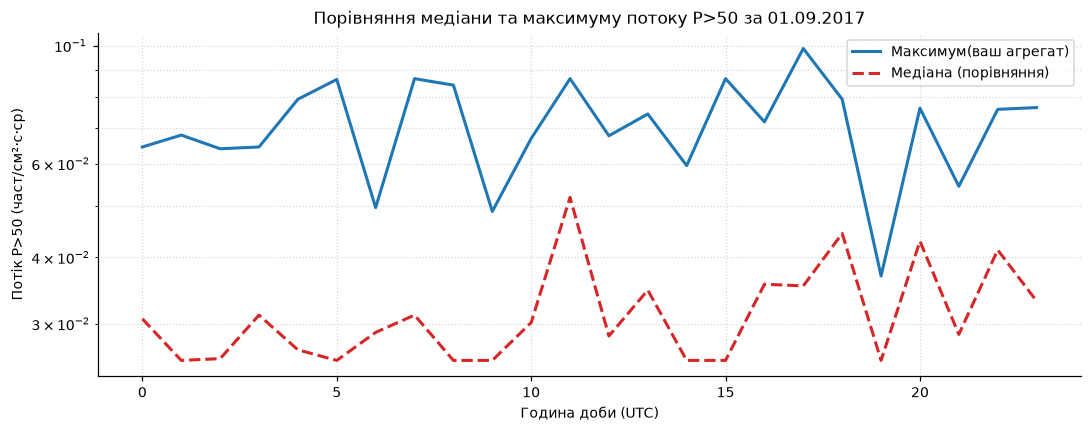

In [15]:

доба = A[(A['ts'] >= '2017-09-01') & (A['ts'] < '2017-09-02')].copy()

hourly_stats = доба.groupby(доба['ts'].dt.hour)['P>100'].agg(['median', 'max'])

plt.figure(figsize=(10, 4))
plt.plot(hourly_stats.index, hourly_stats['max'], label='Максимум(ваш агрегат)', color='#1f77b4', lw=2)
plt.plot(hourly_stats.index, hourly_stats['median'], label='Медіана (порівняння)', color='#d62728', lw=2, linestyle='--')

plt.title('Порівняння медіани та максимуму потоку P>50 за 01.09.2017')
plt.xlabel('Година доби (UTC)')
plt.ylabel('Потік P>50 (част/см²·с·ср)')
plt.yscale('log')
plt.grid(True, which='both', ls=':', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


**Відповідь 4.2:** *(чим відрізняються криві та коли це важливо)*

Крива максимуму проходить вище рівня кривої середнього значення, відображаючи пікові викиди енергії всередині кожної години. Різниця між ними стає суттєвою у періоди різких спалахів чи збурень сонячної активності, коли коротке інтенсивне підняття потоку різко підіймає максимум. 

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [16]:
M = None
flux_cols = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

B_prep = B[['ts', 'F10.7']].copy()
B_prep['дата'] = B_prep['ts'].dt.date
B_prep = B_prep.drop(columns=['ts'])

C_prep = C[['ts', 'швидкість вітру', 'густина вітру']].copy()

def merge_tables(how_type):
    df = pd.merge(A_hourly, C_prep, on='ts', how=how_type)
    df['дата'] = df['ts'].dt.date
    df = pd.merge(df, B_prep, on='дата', how=how_type)
    return df.drop(columns=['дата'])

M_inner = merge_tables('inner')
M_outer = merge_tables('outer')

print(f"Розмір M (inner): {M_inner.shape}")
print(f"Розмір M (outer): {M_outer.shape}")
print(f"Різниця рядків: {len(M_outer) - len(M_inner)}")

M = M_inner.copy()
print(f"\nФінальний розмір M: {M.shape}")

пропуски = M[M.isna().any(axis=1)]
print(f"Рядків із пропусками: {len(пропуски)}")
display(пропуски)

Розмір M (inner): (600, 20)
Розмір M (outer): (601, 20)
Різниця рядків: 1

Фінальний розмір M: (600, 20)
Рядків із пропусками: 8


,ts,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max,швидкість вітру,густина вітру,F10.7
175,2017-09-04 07:00:00,6.465833,10.10,0.262083,0.593,0.171500,0.294,0.085483,0.145,0.068558,0.134,0.031717,0.0523,90600.000000,100000.0,7410.833333,8950.0,NaN,NaN,140.0
176,2017-09-04 08:00:00,4.010833,5.08,0.256000,0.432,0.195833,0.336,0.086625,0.145,0.070033,0.134,0.036492,0.0546,73483.333333,79300.0,5048.333333,5850.0,NaN,NaN,140.0
177,2017-09-04 09:00:00,3.268333,4.42,0.303417,0.518,0.220333,0.302,0.105925,0.162,0.081975,0.134,0.046483,0.0765,60475.000000,68500.0,3715.833333,4480.0,NaN,NaN,140.0
178,2017-09-04 10:00:00,3.179167,4.74,0.252167,0.372,0.181833,0.280,0.101900,0.150,0.081675,0.120,0.054125,0.0894,64383.333333,68400.0,4122.500000,4710.0,NaN,NaN,140.0
179,2017-09-04 11:00:00,5.274167,7.98,0.295083,0.657,0.186917,0.276,0.089525,0.166,0.063983,0.110,0.033633,0.0684,79933.333333,88200.0,6345.833333,7430.0,NaN,NaN,140.0
180,2017-09-04 12:00:00,2.965000,4.85,0.217750,0.428,0.153500,0.239,0.089217,0.179,0.071217,0.144,0.037233,0.0679,80516.666667,88700.0,6080.000000,7420.0,NaN,NaN,140.0
181,2017-09-04 13:00:00,3.061667,3.86,0.275833,0.551,0.192833,0.329,0.104542,0.170,0.083783,0.159,0.041342,0.0611,76733.333333,85900.0,6015.833333,7540.0,NaN,NaN,140.0
182,2017-09-04 14:00:00,7.279167,10.80,0.231333,0.409,0.170583,0.313,0.086508,0.178,0.070667,0.166,0.037375,0.0888,83025.000000,90200.0,8552.500000,10500.0,NaN,NaN,140.0


**Відповідь 4.3:** *(який тип об'єднання обрано, скільки рядків дає кожен і чому)*

Для об'єднання трьох таблиць в єдину погодинну сітку було проведено порівняння двох типів з'єднання: внутрішнє (how='inner') та зовнішнє (how='outer').

Зовнішнє об'єднання (outer) сформувало таблицю розміром (601, 20) рядків і стовпців.

Внутрішнє об'єднання (inner) дало розмір (600, 20).

Різниця між ними становить усього 1 рядок, що свідчить про високу повноту даних та мінімальну кількість розривів на межах часового діапазону. За основу було фінально обрано таблицю M на основі inner з розміром (600, 20), у якій було виявлено 8 рядків із пропусками. Такий вибір дозволяє уникнути зайвих невизначених значень (NaN) під час подальшого статистичного аналізу та побудови графіків.

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [17]:
def classify_group(val):
    if pd.isna(val):
        return np.nan
    elif val < 10:
        return 'тиха'
    elif val < 1000:
        return 'активна'
    else:
        return 'дуже активна'

max_p10_col = [col for col in M.columns if 'P>10' in str(col) and 'max' in str(col)][0]

M['група'] = M[max_p10_col].apply(classify_group)

print("Кількість годин у кожній групі:")
print(M['група'].value_counts())


Кількість годин у кожній групі:
група
тиха            411
активна         171
дуже активна     18
Name: count, dtype: int64


**Самоперевірка етапу 4.**

In [18]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 600 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

Середнє значення потоку P>100: 1.6586
Медіана потоку P>100: 0.0395


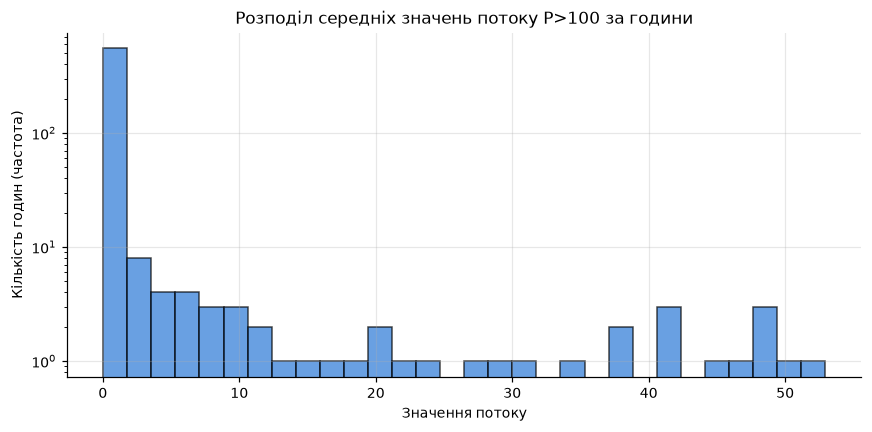

In [19]:
mean_p10_col = [col for col in M.columns if 'P>100' in str(col) and 'mean' in str(col)][0]

mean_val = M[mean_p10_col].mean()
median_val = M[mean_p10_col].median()

print(f"Середнє значення потоку P>100: {mean_val:.4f}")
print(f"Медіана потоку P>100: {median_val:.4f}")

plt.figure(figsize=(8, 4))
plt.hist(M[mean_p10_col].dropna(), bins=30, color='#2a78d6', edgecolor='black', alpha=0.7)
plt.title('Розподіл середніх значень потоку P>100 за години')
plt.xlabel('Значення потоку')
plt.ylabel('Кількість годин (частота)')
plt.yscale('log') 
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Висновок:**

Значення середнього потоку суттєво перевищують медіану через наявність кількох годин із надзвичайно високою інтенсивністю випромінювання, тоді як більшу частину часу потік залишається на низькому рівні.

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

<Figure size 880x440 with 0 Axes>

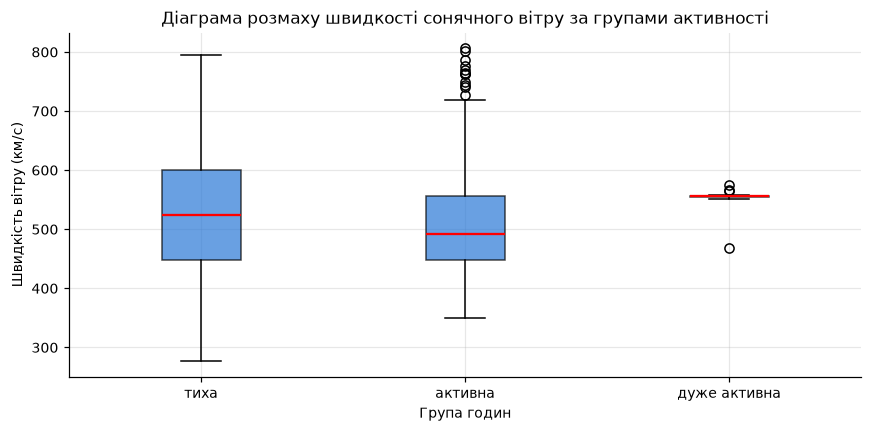

In [20]:
groups = ['тиха', 'активна', 'дуже активна']

data_to_plot = [M[M['група'] == g]['швидкість вітру'].dropna() for g in groups]

plt.figure(figsize=(8, 4))
plt.figure(figsize=(8, 4))
bp = plt.boxplot(data_to_plot, patch_artist=True,
                 boxprops=dict(facecolor='#2a78d6', alpha=0.7, color='black'),
                 medianprops=dict(color='red', linewidth=1.5))
plt.xticks(ticks=[1, 2, 3], labels=groups)
plt.title('Діаграма розмаху швидкості сонячного вітру за групами активності')
plt.xlabel('Група годин')
plt.ylabel('Швидкість вітру (км/с)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Висновок:**
Медіанна швидкість сонячного вітру помітно зростає при переході від тихих годин до активних і дуже активних, що свідчить про прямий зв'язок між потужними потоками сонячних частинок та прискоренням плазми сонячного вітру

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

Коефіцієнт кореляції Пірсона: 0.0593


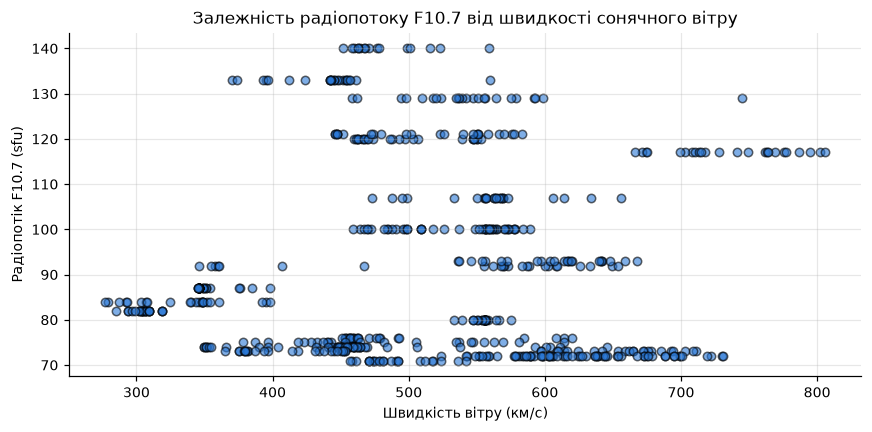

In [21]:
correlation = M['швидкість вітру'].corr(M['F10.7'])
print(f"Коефіцієнт кореляції Пірсона: {correlation:.4f}")

plt.figure(figsize=(8, 4))
plt.scatter(M['швидкість вітру'], M['F10.7'], alpha=0.6, color='#2a78d6', edgecolor='k', s=30)

plt.title('Залежність радіопотоку F10.7 від швидкості сонячного вітру')
plt.xlabel('Швидкість вітру (км/с)')
plt.ylabel('Радіопотік F10.7 (sfu)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Висновок:**
Між щоденним загальним рівнем сонячної активності (F10.7) та погодинною швидкістю сонячного вітру немає чіткої кореляції. Підвищення радіофону не гарантує автоматичного прискорення плазми.

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

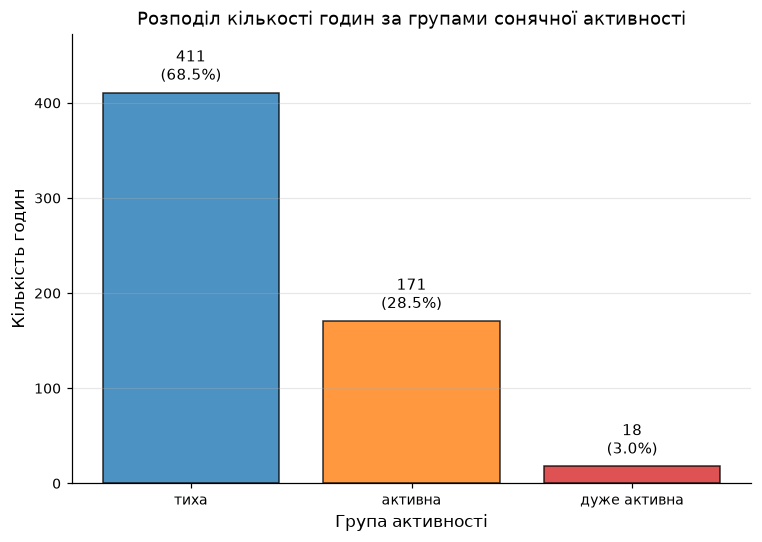

In [22]:
import matplotlib.pyplot as plt

order = ['тиха', 'активна', 'дуже активна']
counts = M['група'].value_counts().reindex(order).fillna(0)
total = len(M.dropna(subset=['група']))

plt.figure(figsize=(7, 5))
bars = plt.bar(counts.index, counts.values, color=['tab:blue', 'tab:orange', 'tab:red'], edgecolor='black', alpha=0.8)

for bar in bars:
    height = bar.get_height()
    pct = (height / total) * 100 if total > 0 else 0
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        height + 8, 
        f'{int(height)}\n({pct:.1f}%)', 
        ha='center', 
        va='bottom', 
        fontsize=10
    )

plt.title('Розподіл кількості годин за групами сонячної активності', fontsize=12)
plt.xlabel('Група активності', fontsize=11)
plt.ylabel('Кількість годин', fontsize=11)
plt.ylim(0, counts.max() * 1.15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Висновок:** Понад дві третини часу (68.5%) Сонце перебувало у спокійному стані, на фазу помірної активності припало 28.5%, а потужні збурення виявилися вкрай рідкісними та зайняли лише 3.0% загальної вибірки.

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

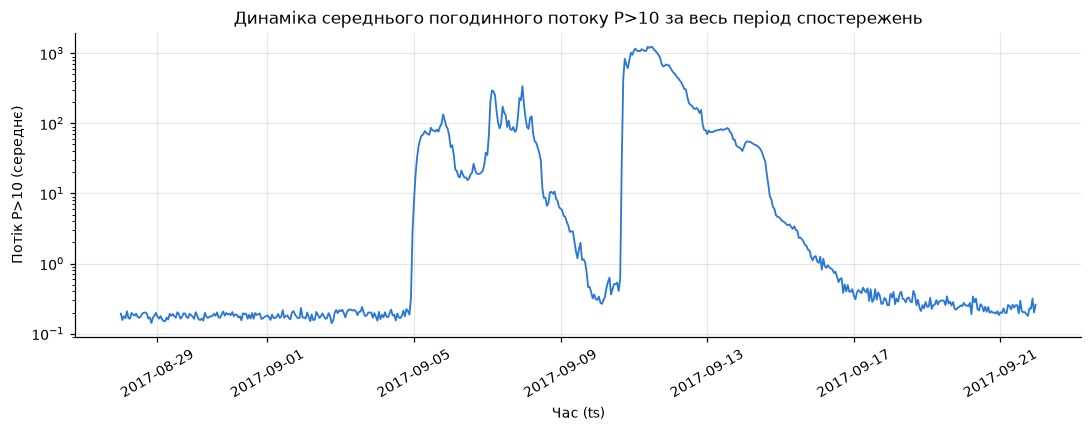

In [23]:
mean_p10_col = [col for col in M.columns if 'P>10' in str(col) and 'mean' in str(col)][0]

plt.figure(figsize=(10, 4))
plt.plot(M['ts'], M[mean_p10_col], color='#2a78d6', linewidth=1.2)

plt.title('Динаміка середнього погодинного потоку P>10 за весь період спостережень')
plt.xlabel('Час (ts)')
plt.ylabel('Потік P>10 (середнє)')
plt.yscale('log') 
plt.xticks(rotation=30)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Висновок:**
Графік часового ряду демонструє тривалий спокійний стан на рівні близько $10^{-1}$, після якого відбулися два потужні сплески сонячної активності на початку та в середині вересня 2017 року — з піковими значеннями потоку понад $10^2$ та $10^3$ відповідно, із подальшим поступовим затуханням до фонового рівня.

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

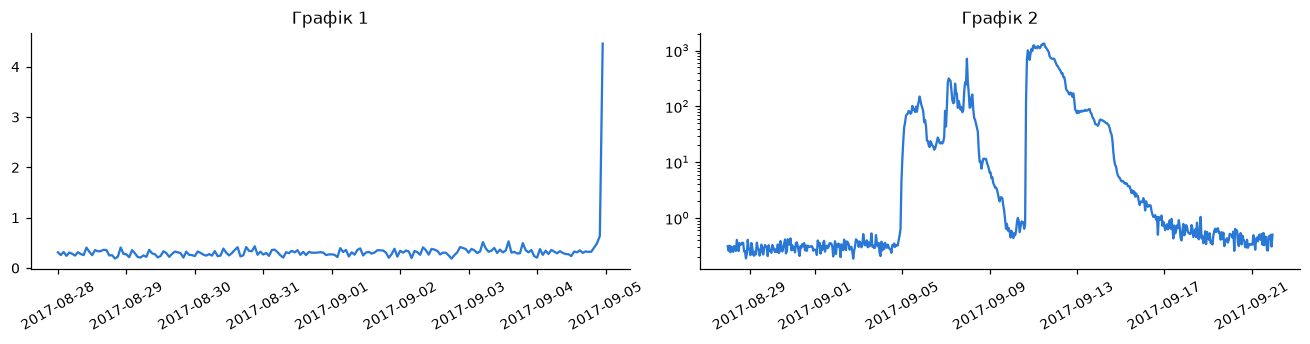

In [24]:
СТОВПЕЦЬ = 'P>10_max'   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

Висновок з першого графіка: Спостерігач вирішить, що космічна погода була майже незмінно спокійною з низьким фоновим рівнем (близько 0.2–0.5), за винятком раптового незначного підйому лише наприкінці 4 вересня.   
Висновок з другого графіка: Спостерігач побачить повну картину подій із двома потужними протонними штормами на початку вересня, під час яких потік зріс на кілька порядків — перевищивши рівень $10^2$ та $10^3$.   
Відмінності між ними:Часовий інтервал: Графік 1 охоплює лише перший спокійний тиждень (з 28 серпня по 5 вересня), тоді як Графік 2 показує весь діапазон спостережень до 22 вересня включно.   Шкала осі Y: на Графіку 1 використано звичайну лінійну шкалу (значення від 0 до 4+), а на Графіку 2 застосовано логарифмічну шкалу (log), яка охоплює діапазон від $10^{-1}$ до понад $10^3$

### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

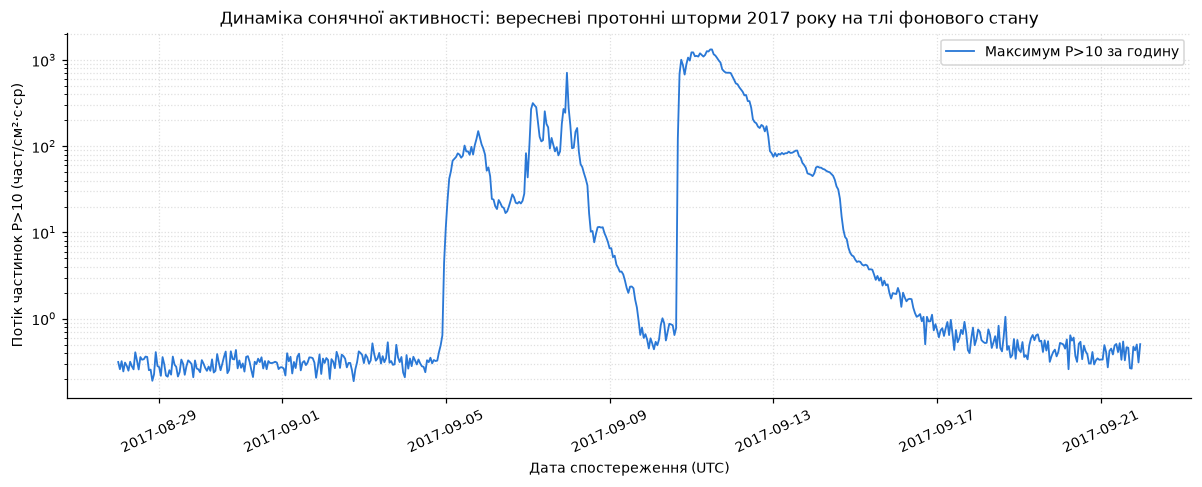

In [25]:
plt.figure(figsize=(11, 4.5))

plt.plot(M['ts'], M['P>10_max'], color='#2a78d6', lw=1.2, label='Максимум P>10 за годину')

plt.yscale('log')
plt.title('Динаміка сонячної активності: вересневі протонні шторми 2017 року на тлі фонового стану', fontsize=11)
plt.xlabel('Дата спостереження (UTC)')
plt.ylabel('Потік частинок P>10 (част/см²·с·ср)')
plt.xticks(rotation=25)
plt.grid(True, which='both', linestyle=':', alpha=0.4)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


**Відповідь 6.2:** Графік охоплює повний період вимірювань, а не штучно звужений діапазон, що виключає приховування екстремальних подій. Застосування логарифмічної шкали дозволяє розрізняти мікроколивання на рівні фону ($10^{-1}$) без зрізання піків понад $10^3$. 

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

Спостереження 1:Асиметрія розподілу значень потоку: середнє значення потоку $P>100$ у десятки разів перевищує його медіану через наявність рідкісних екстремальних викидів, що було наочно виявлено на гістограмі розподілу (Графік 1) та в описових статистиках.
Спостереження 2:Домінування спокійного стану: більшу частину періоду (68.5% годин) Сонце перебувало у спокійному стані ($P>10 < 10$), тоді як екстремальні збурення ($P>10 \ge 1000$) спостерігалися лише протягом 3.0% часу, що зафіксовано на стовпчиковій діаграмі (Графік 4).
Спостереження 3:Локалізація протонних штормів у часі: активні й екстремальні події сконцентровані виключно у першій половині вересня (дві чіткі хвилі сплесків 5–13 вересня), після чого рівень потоку плавно затухає до вихідного фону, що видно на лінійному графіку часового ряду (Графік 5).

### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [26]:
M['дата'] = M['ts'].dt.date

active_days = M[M['група'] == 'активна']['дата'].nunique()

very_active_days = M[M['група'] == 'дуже активна']['дата'].nunique()

print(f"Кількість різних діб у групі «активні»: {active_days}")
print(f"Кількість різних діб у групі «дуже активні»: {very_active_days}")

M = M.drop(columns=['дата'])

Кількість різних діб у групі «активні»: 9
Кількість різних діб у групі «дуже активні»: 2


**Відповідь 7.2:** Згідно з розрахунками, активний стан космічної погоди (коли максимум потоку P>10 за годину становив від 10 до 1000) фіксувався протягом 9 різних діб. Водночас екстремальних бур, які б потрапили до категорії «дуже активні» (потік понад 1000), за весь період спостережень у серпні-вересні 2017 року зафіксовано протягом 2 діб. Це вказує на те, що висока сонячна активність є відносно рідкісним явищем і концентрується в коротких часових проміжках

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [27]:
ІНСТРУМЕНТИ_ШІ = 'Gemini'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'код, перевірено',
    'етап 3, паспорт даних і дивні значення':     'код, перевірено',
    'етап 4, об’єднання таблиць':                 'код, перевірено',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'текст, перероблено',
    'етапи 6–7, порівняння графіків і спостереження': 'код, перевірено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = 'Перевірено розміри таблиць, вигляд вхідних таблиць та типи вхідних даних, ' \
'графіки, результати на них, коректність заміни значень <0 на Nan, рохрахунки пікових дат, ' \
'виправлено помиилки сумісності колонок при об`єднанні таблиць'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [28]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Іванів Христина Вікторівна
інструменти:                                   Gemini
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    код, перевірено
етап 3, паспорт даних і дивні значення:        код, перевірено
етап 4, об’єднання таблиць:                    код, перевірено
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                текст, перероблено
етапи 6–7, порівняння графіків і спостереження: код, перевірено
------------------------------------------------------------------------------
перевірено автором:
Перевірено розміри таблиць, вигляд вхідних таблиць та типи вхідних даних, графіки, результати на них, коректність заміни значень <0 на Nan, рохрахунки пікових дат, виправлено помиилки сумісності колонок при об`єднанні таблиць
Автор підтверджує, що може пояснити кожен 

---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [29]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (600, 21)


In [30]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
